In [1]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Conexión (puedes cambiar nombre_bd según la entrega)
conn = mysql.connector.connect(
    host='212.227.90.6',
    user='Equipo19',
    password='E1q2u3i4p5o19',
    database='Equip_19'
)

cursor = conn.cursor()

# Obtener nombres de tablas
cursor.execute("SHOW TABLES")
tablas = [t[0] for t in cursor.fetchall()]

# Guardar todas las tablas en un diccionario de DataFrames
dfs = {tabla: pd.read_sql(f"SELECT * FROM {tabla}", conn) for tabla in tablas}

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\2116393161.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs = {tabla: pd.read_sql(f"SELECT * FROM {tabla}", conn) for tabla in tablas}


In [2]:
df = dfs['Tourist_Accommodation03112025']

In [41]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date'],
      dtype='object')

In [3]:
df.describe().round(2)

,apartment_id,host_id,accommodates,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,8000.00,8.000000e+03,8000.00,7992.00,7829.00,8000.00,8000.00,8000.00,8000.00,8000.0,8000.00,8000.00,6304.00,6295.00,6301.00,6290.00,6299.00,6289.00,6289.00,6386.00
mean,16965762.19,7.086559e+07,4.33,2.97,1007.75,4.57,761.23,12.39,27.61,44.6,188.34,31.36,919.70,94.56,93.16,96.28,96.35,95.32,91.41,125.47
std,8733606.94,6.575185e+07,2.59,2.29,844.35,11.81,497.95,11.52,22.41,33.0,129.64,57.08,89.07,9.24,9.96,8.04,7.93,7.51,9.64,155.40
min,11964.00,1.070400e+04,1.00,0.00,60.00,1.00,1.00,0.00,0.00,0.0,0.00,0.00,200.00,20.00,20.00,20.00,20.00,20.00,20.00,1.00
25%,10762147.00,1.196814e+07,2.00,1.00,450.00,1.00,62.00,0.00,2.00,9.0,67.00,1.00,890.00,90.00,90.00,90.00,90.00,90.00,90.00,17.00
50%,18075218.50,4.835305e+07,4.00,2.00,750.00,2.00,1125.00,10.00,27.00,47.0,190.00,8.00,940.00,100.00,100.00,100.00,100.00,100.00,90.00,58.00
75%,23625424.00,1.184978e+08,6.00,4.00,1220.00,4.00,1125.00,24.00,50.00,76.0,316.00,36.00,980.00,100.00,100.00,100.00,100.00,100.00,100.00,181.00
max,32423292.00,3.365242e+08,29.00,30.00,6071.00,365.00,1125.00,30.00,60.00,90.0,365.00,588.00,1000.00,100.00,100.00,100.00,100.00,100.00,100.00,1291.00


In [4]:
dfnumerics = df

In [5]:
dfnumerics = dfnumerics.drop('apartment_id', axis=1)

In [6]:
dfnumerics= dfnumerics.drop('host_id',axis=1)

In [7]:
stadistics = dfnumerics.describe().round(2)
stadistics

,accommodates,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,8000.00,7992.00,7829.00,8000.00,8000.00,8000.00,8000.00,8000.0,8000.00,8000.00,6304.00,6295.00,6301.00,6290.00,6299.00,6289.00,6289.00,6386.00
mean,4.33,2.97,1007.75,4.57,761.23,12.39,27.61,44.6,188.34,31.36,919.70,94.56,93.16,96.28,96.35,95.32,91.41,125.47
std,2.59,2.29,844.35,11.81,497.95,11.52,22.41,33.0,129.64,57.08,89.07,9.24,9.96,8.04,7.93,7.51,9.64,155.40
min,1.00,0.00,60.00,1.00,1.00,0.00,0.00,0.0,0.00,0.00,200.00,20.00,20.00,20.00,20.00,20.00,20.00,1.00
25%,2.00,1.00,450.00,1.00,62.00,0.00,2.00,9.0,67.00,1.00,890.00,90.00,90.00,90.00,90.00,90.00,90.00,17.00
50%,4.00,2.00,750.00,2.00,1125.00,10.00,27.00,47.0,190.00,8.00,940.00,100.00,100.00,100.00,100.00,100.00,90.00,58.00
75%,6.00,4.00,1220.00,4.00,1125.00,24.00,50.00,76.0,316.00,36.00,980.00,100.00,100.00,100.00,100.00,100.00,100.00,181.00
max,29.00,30.00,6071.00,365.00,1125.00,30.00,60.00,90.0,365.00,588.00,1000.00,100.00,100.00,100.00,100.00,100.00,100.00,1291.00


In [8]:
stadistics.to_csv('stadistics Equip_19.csv',index=False)

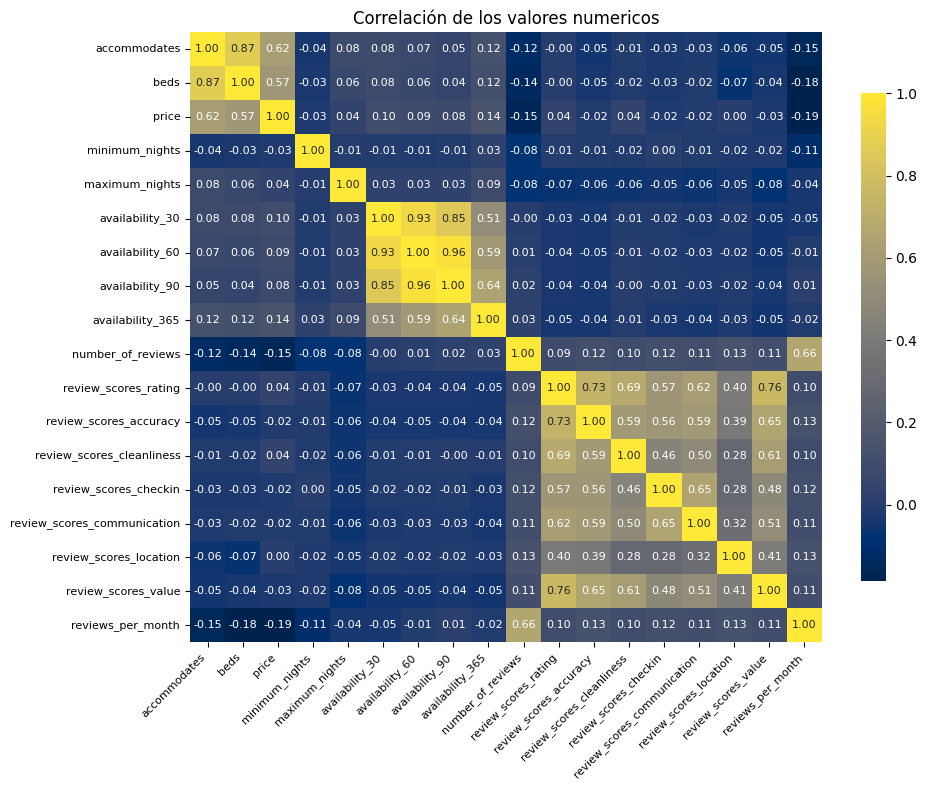

In [9]:
correl = dfnumerics.select_dtypes('number')

plt.figure(figsize=(10, 8))
sns.heatmap(
    correl.corr(),
    annot=True,
    cmap='cividis',
    fmt=".2f",                      # limits to 2 decimals
    annot_kws={"size": 8},          # controls number text size
    cbar_kws={"shrink": 0.8}        # makes colorbar smaller
)
plt.title(
    'Correlación de los valores numericos',
    fontsize=12                     # smaller title
)
plt.xticks(fontsize=8, rotation=45, ha='right')  # smaller rotated labels
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date'],
      dtype='object')

In [11]:
roomsFilter = df.loc[:,
                     ['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
                    'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
                    'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
                    'maximum_nights', 'has_availability', 'availability_30',
                    'availability_60', 'availability_90', 'availability_365','city'
                         
                     ]
                     ]
roomsFilter

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,city
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,None,Private room,2,2,1,...,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,VERDADERO,7,20,40,130,malaga
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1,1,...,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,VERDADERO,0,0,0,162,madrid
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2,...,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,VERDADERO,26,31,31,270,sevilla
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2,1,...,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,VERDADERO,9,23,49,300,barcelona
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,None,Private room,5,1,2,...,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,VERDADERO,0,19,49,312,girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,32392193,Espectacular habitaci�n,None,238089984,Sant Antoni,Eixample,Private room,1,1,1,...,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",3000.0,32,1125,VERDADERO,28,58,88,363,barcelona
7996,32392774,? Tu Hogar de Lujo ????? en el Centro de Sevilla,"Exclusivo, amplio y luminoso alojamiento situa...",243246681,Arenal,Casco Antiguo,Entire home/apt,6,2,3,...,"Patio or balcony, Long term stays allowed, Sha...",2090.0,2,60,VERDADERO,0,11,41,41,sevilla
7997,32395123,Rooms by G Bella Mar�a 3,The 2-star Bella Maria has 24-hourreception an...,159933359,Felanitx,None,Entire home/apt,2,1,1,...,"Air conditioning,Pool,Kitchen,Free parking on ...",930.0,1,1125,VERDADERO,23,53,83,184,mallorca
7998,32407332,LUMINOSO Y ENCANTADOR PISO CERCA DE TODO,PISO MUY ILUMINADO CON UNA TERRAZA ESTUPENDA C...,187631805,Proven�als del Poblenou,Sant Mart�,Private room,3,2,2,...,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",960.0,2,15,VERDADERO,1,17,40,315,barcelona


In [12]:
reviewsFilter = df.loc[:,
                       ['number_of_reviews', 'first_review_date', 'last_review_date',
                        'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month','city','insert_date'
                           
                       ]
                       ]
reviewsFilter

,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,city,insert_date
0,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,malaga,31/07/2018
1,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,madrid,10/01/2020
2,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,sevilla,29/07/2019
3,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,barcelona,10/01/2020
4,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,girona,19/02/2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,barcelona,16/10/2019
7996,36,17/03/2019,09/09/2020,1000.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,157.0,sevilla,31/01/2021
7997,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,mallorca,24/04/2019
7998,21,04/03/2019,28/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,389.0,barcelona,12/08/2019


In [13]:
rooms = df.loc[:,
                ['accommodates', 'bathrooms',
                'bedrooms', 'beds', 'price', 'minimum_nights',
                'maximum_nights', 'availability_30',
                'availability_60', 'availability_90', 'availability_365']
               ]
rooms

,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365
0,2,2,1,1.0,400.0,3,365,7,20,40,130
1,1,1,1,1.0,170.0,4,40,0,0,0,162
2,4,1,2,2.0,990.0,2,120,26,31,31,270
3,2,2,1,1.0,400.0,2,730,9,23,49,300
4,5,1,2,5.0,900.0,1,180,0,19,49,312
...,...,...,...,...,...,...,...,...,...,...,...
7995,1,1,1,1.0,3000.0,32,1125,28,58,88,363
7996,6,2,3,4.0,2090.0,2,60,0,11,41,41
7997,2,1,1,2.0,930.0,1,1125,23,53,83,184
7998,3,2,2,2.0,960.0,2,15,1,17,40,315


In [14]:
reviews = df.loc[:, 
                    ['number_of_reviews', 'first_review_date', 'last_review_date',
                    'review_scores_rating', 'review_scores_accuracy',
                    'review_scores_cleanliness', 'review_scores_checkin',
                    'review_scores_communication', 'review_scores_location',
                    'review_scores_value']
                    ]
reviews


,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0
1,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0
2,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0
3,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0
4,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...
7995,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7996,36,17/03/2019,09/09/2020,1000.0,100.0,100.0,100.0,100.0,100.0,100.0
7997,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7998,21,04/03/2019,28/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0


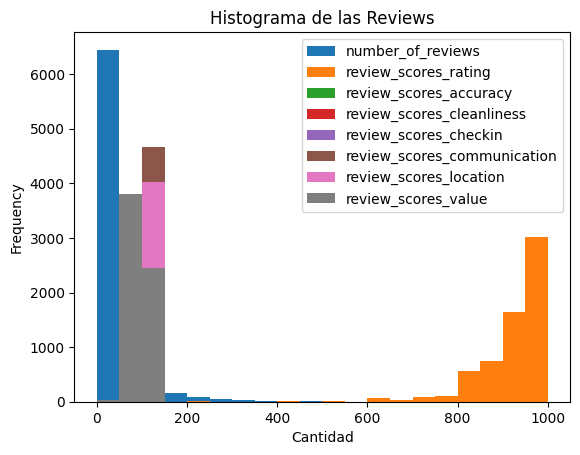

In [15]:
reviewsPlot = reviews.plot.hist(bins=20)
plt.title('Histograma de las Reviews')
plt.xlabel('Cantidad')
plt.show()

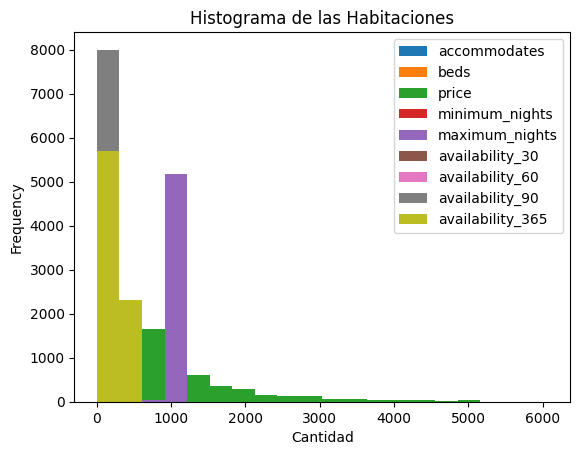

In [16]:
roomsPlot = rooms.plot.hist(bins=20)
plt.title('Histograma de las Habitaciones')
plt.xlabel('Cantidad')
plt.show()

<Figure size 5000x600 with 0 Axes>

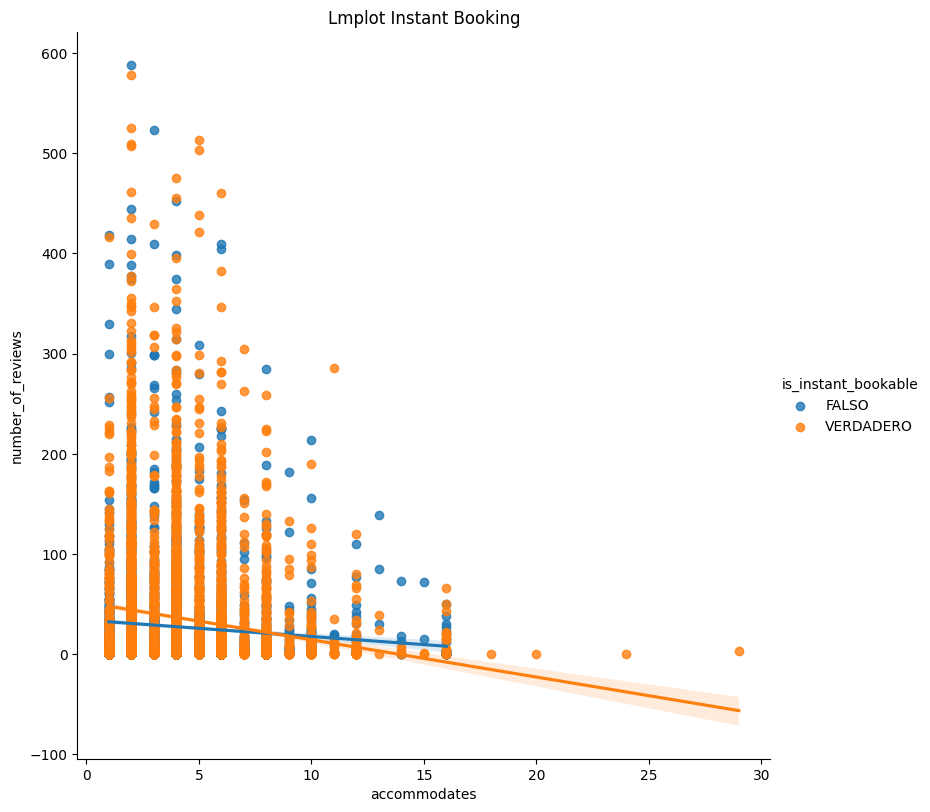

In [17]:
plt.figure(figsize=(50, 6))
sns.lmplot(data = df, x='accommodates', y='number_of_reviews',hue = 'is_instant_bookable',height=8)
plt.title('Lmplot Instant Booking')
plt.show()

<Figure size 5000x600 with 0 Axes>

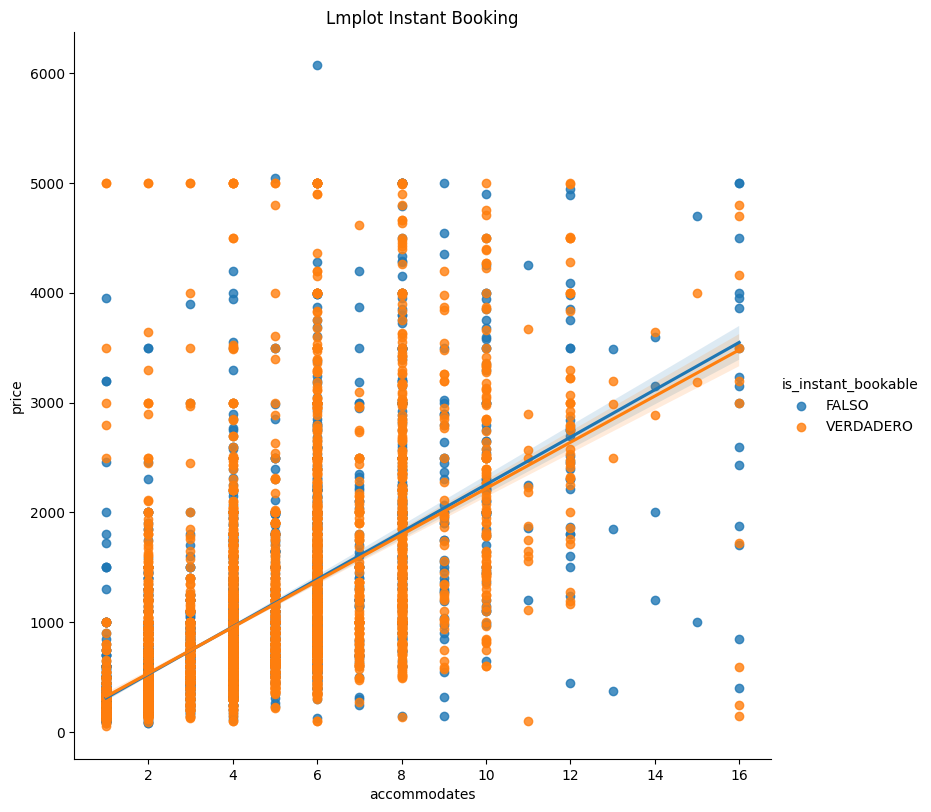

In [18]:
plt.figure(figsize=(50, 6))
sns.lmplot(data = df, x='accommodates', y='price',hue = 'is_instant_bookable',height=8)
plt.title('Lmplot Instant Booking')
plt.show()

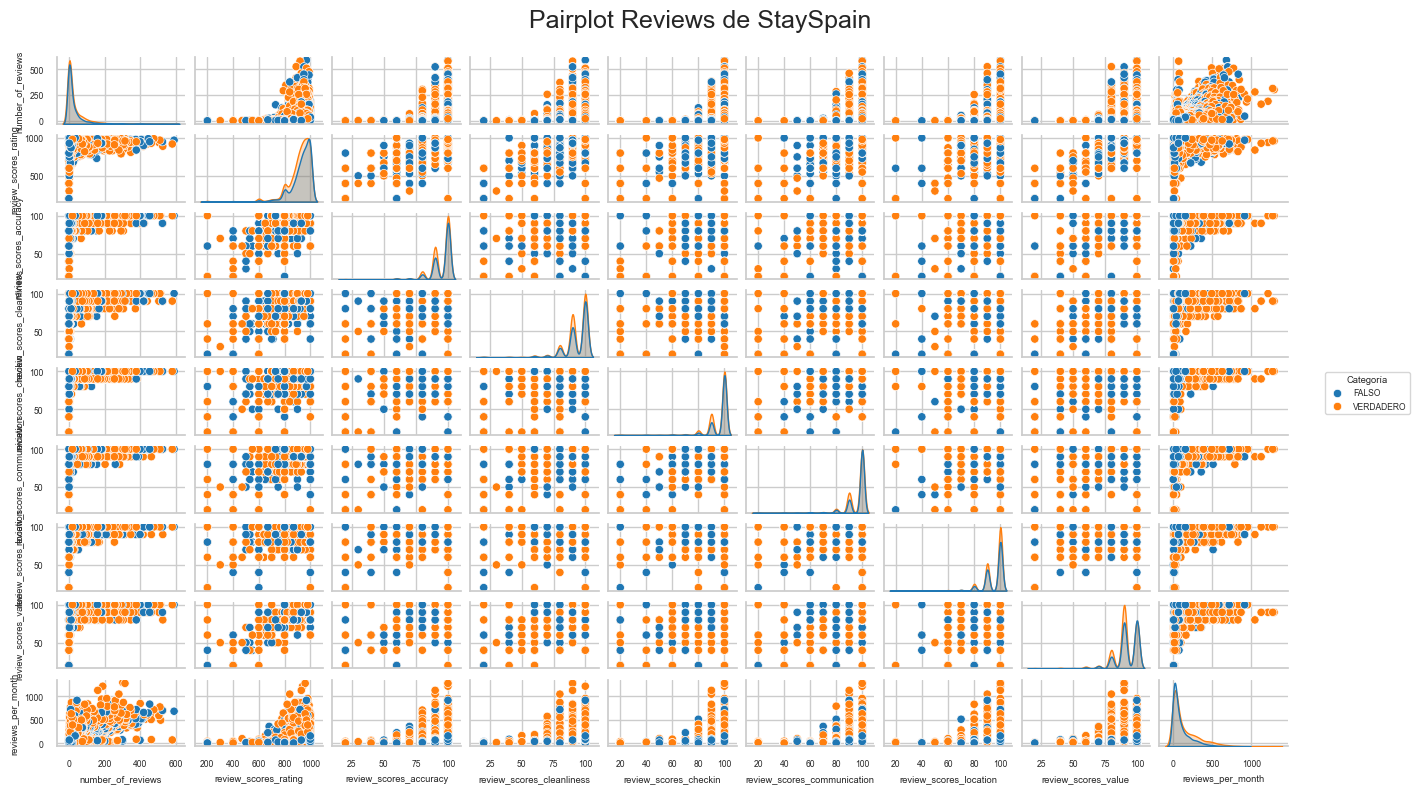

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("notebook", font_scale=0.56) 
sns.set_style("whitegrid")
plot = sns.pairplot(reviewsFilter,hue='is_instant_bookable')

plot.fig.set_size_inches(14, 8)  # (ancho, alto)

plot.fig.tight_layout()
plot.fig.subplots_adjust(top=0.92, right=0.92)

plot.fig.suptitle('Pairplot Reviews de StaySpain', fontsize=18)

plot._legend.set_bbox_to_anchor((1.01, 0.5))  # (x, y) → x > 1 para que salga fuera  # opción para ponerle un borde
plot._legend.set_title("Categoría")  # cambia el título de la leyenda si quieres
plot._legend.set_frame_on(True)

plt.show()

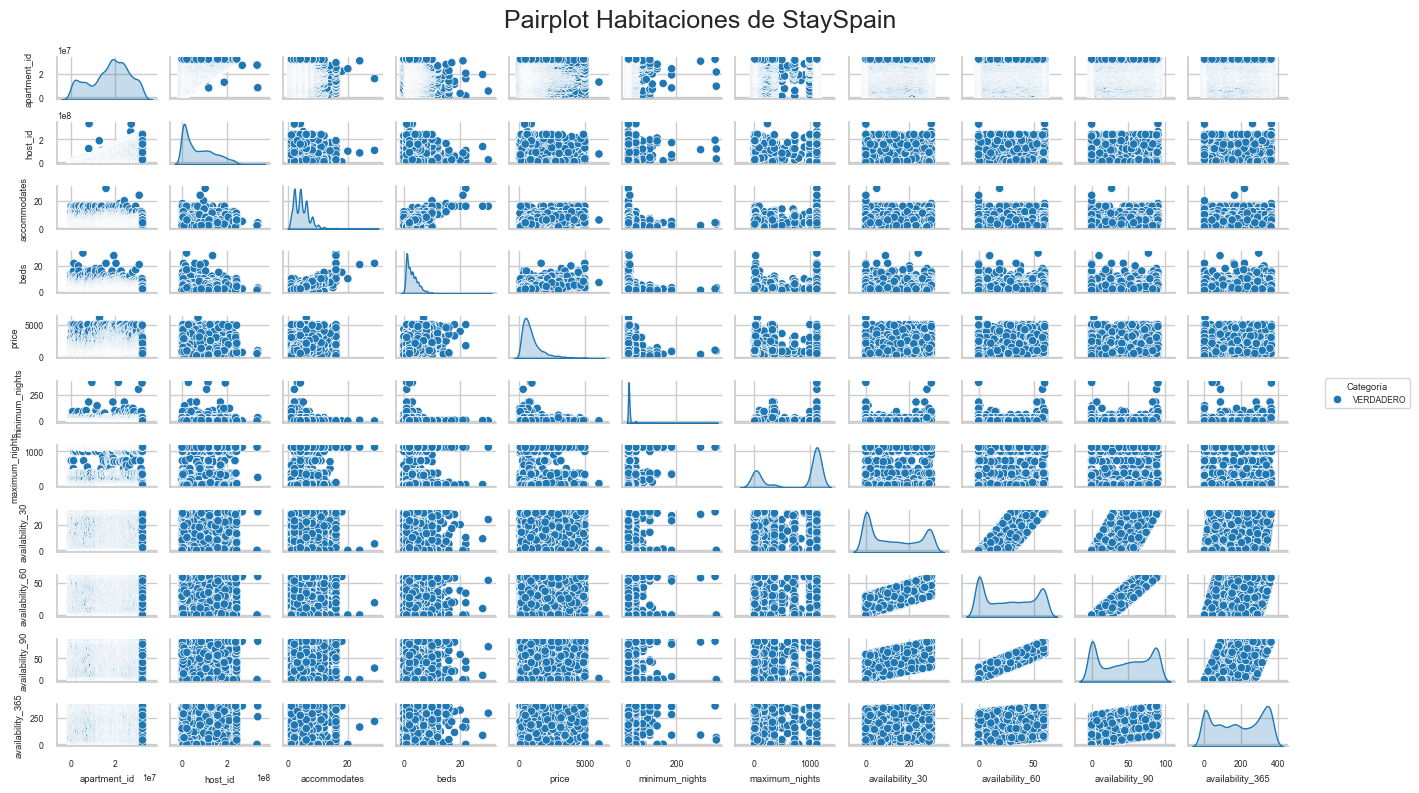

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("notebook", font_scale=0.56) 
sns.set_style("whitegrid")
plot = sns.pairplot(roomsFilter,hue='has_availability')

plot.fig.set_size_inches(14, 8)  # (ancho, alto)

plot.fig.tight_layout()
plot.fig.subplots_adjust(top=0.92, right=0.92)

plot.fig.suptitle('Pairplot Habitaciones de StaySpain', fontsize=18)

plot._legend.set_bbox_to_anchor((1.01, 0.5))  # (x, y) → x > 1 para que salga fuera  # opción para ponerle un borde
plot._legend.set_title("Categoría")  # cambia el título de la leyenda si quieres
plot._legend.set_frame_on(True)

plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\2570435625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='accommodates', ylabel='price'>

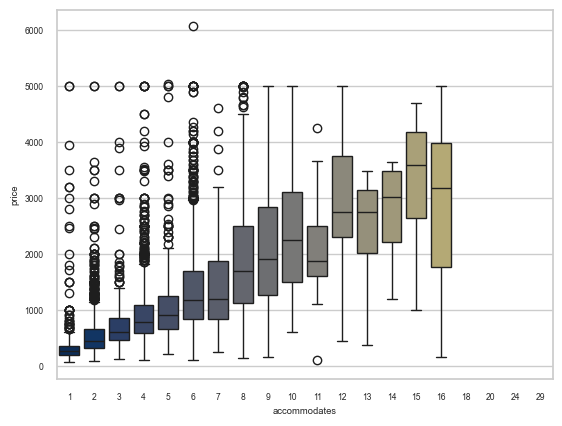

In [21]:
sns.boxplot(
    data=dfnumerics,
    x='accommodates',
    y='price',
    palette='cividis'
)


In [22]:
reviewsFilter

,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,city,insert_date
0,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,malaga,31/07/2018
1,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,madrid,10/01/2020
2,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,sevilla,29/07/2019
3,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,barcelona,10/01/2020
4,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,girona,19/02/2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,barcelona,16/10/2019
7996,36,17/03/2019,09/09/2020,1000.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,157.0,sevilla,31/01/2021
7997,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,mallorca,24/04/2019
7998,21,04/03/2019,28/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,389.0,barcelona,12/08/2019


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\1511481106.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='number_of_reviews'>

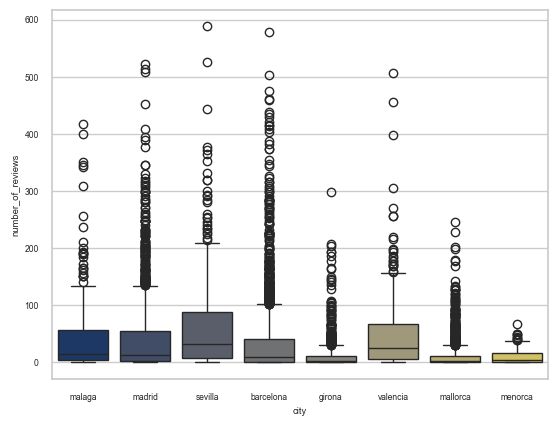

In [23]:
sns.boxplot(
    data=reviewsFilter,
    x='city',
    y='number_of_reviews',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\3277157076.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='price'>

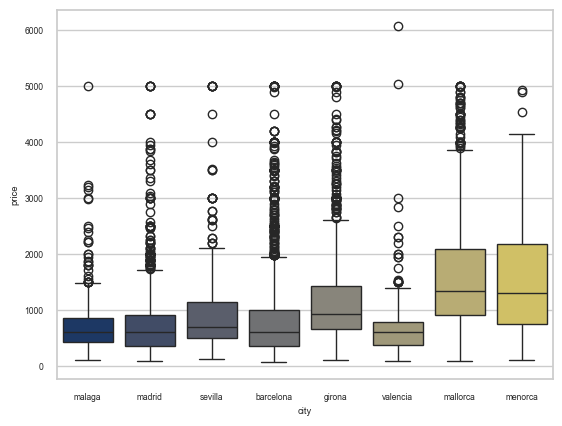

In [24]:
sns.boxplot(
    data=roomsFilter,
    x='city',
    y='price',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\2958375681.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='room_type', ylabel='price'>

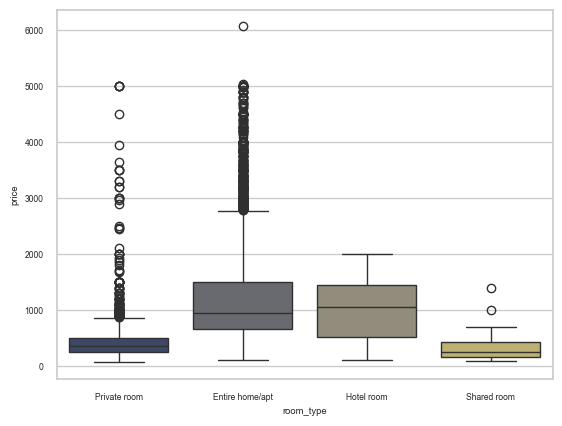

In [25]:
sns.boxplot(
    data=roomsFilter,
    x='room_type',
    y='price',
    palette='cividis'
)

In [26]:
# sns.boxplot(
#     data=roomsFilter,
#     x='apartment_id',
#     y='price',
#     palette='cividis'
# )

In [27]:
roomsFilter.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365', 'city'],
      dtype='object')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\1233295759.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='bedrooms', ylabel='price'>

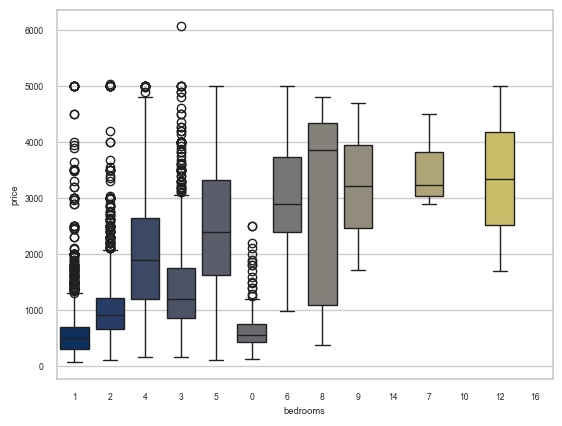

In [28]:
sns.boxplot(
    data=roomsFilter,
    x='bedrooms',
    y='price',
    palette='cividis'
)

In [29]:
reviewsFilter

,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,city,insert_date
0,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,malaga,31/07/2018
1,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,madrid,10/01/2020
2,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,sevilla,29/07/2019
3,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,barcelona,10/01/2020
4,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,girona,19/02/2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,barcelona,16/10/2019
7996,36,17/03/2019,09/09/2020,1000.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,157.0,sevilla,31/01/2021
7997,0,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VERDADERO,NaN,mallorca,24/04/2019
7998,21,04/03/2019,28/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,389.0,barcelona,12/08/2019


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\2974616239.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='reviews_per_month'>

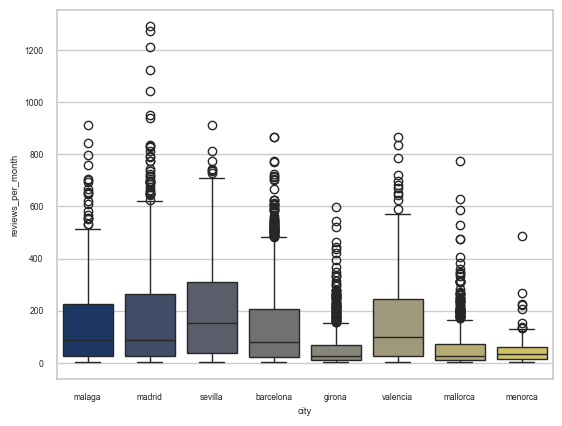

In [30]:
sns.boxplot(
    data=reviewsFilter,
    x='city',
    y='reviews_per_month',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\2798830327.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='review_scores_rating'>

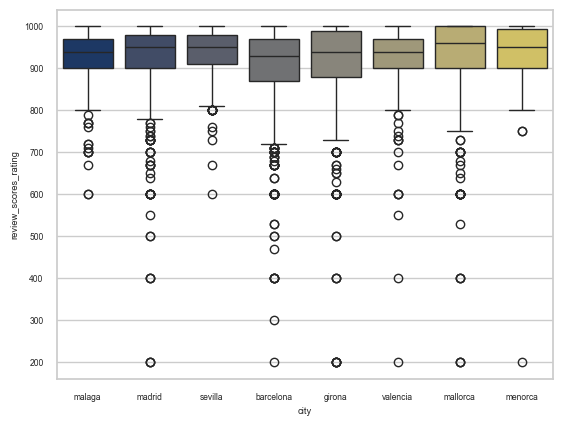

In [31]:
sns.boxplot(
    data=reviewsFilter,
    x='city',
    y='review_scores_rating',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\1095599709.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='review_scores_value'>

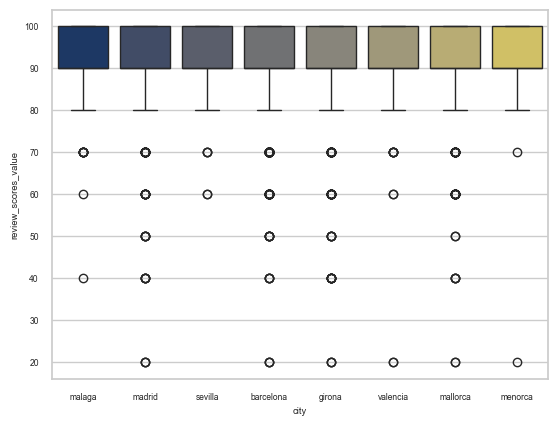

In [32]:
sns.boxplot(
    data=reviewsFilter,
    x='city',
    y='review_scores_value',
    palette='cividis'
)

In [33]:
roomsFilter.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365', 'city'],
      dtype='object')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\695336772.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='availability_30'>

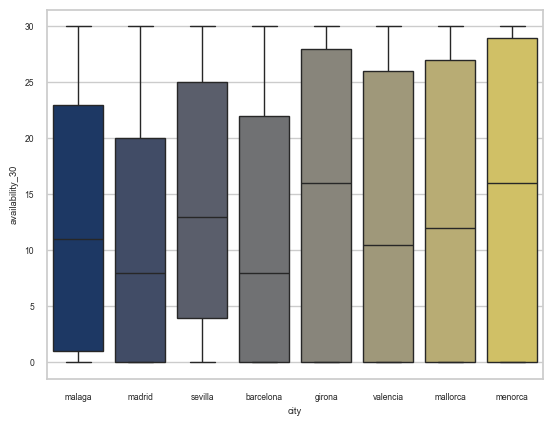

In [34]:
sns.boxplot(
    data=roomsFilter,
    x='city',
    y='availability_30',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\3556815173.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='availability_60'>

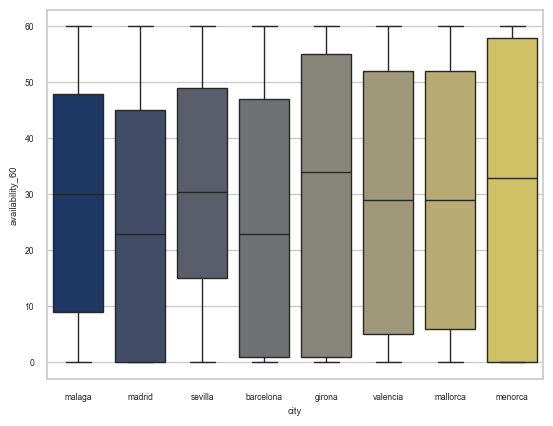

In [35]:
sns.boxplot(
    data=roomsFilter,
    x='city',
    y='availability_60',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\3260253664.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='availability_90'>

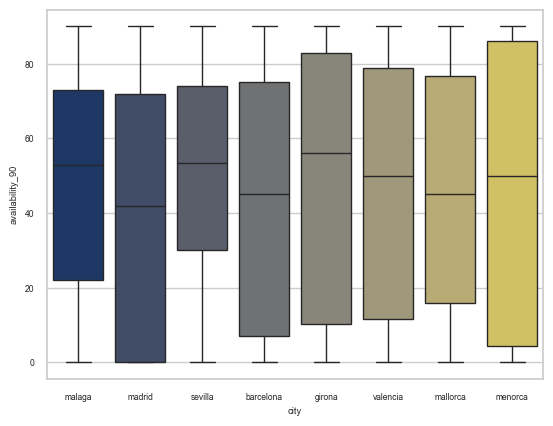

In [36]:
sns.boxplot(
    data=roomsFilter,
    x='city',
    y='availability_90',
    palette='cividis'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4420\1577553409.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='city', ylabel='availability_365'>

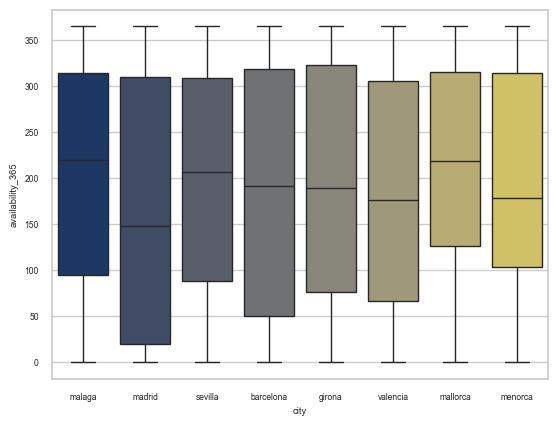

In [37]:
sns.boxplot(
    data=roomsFilter,
    x='city',
    y='availability_365',
    palette='cividis'
)

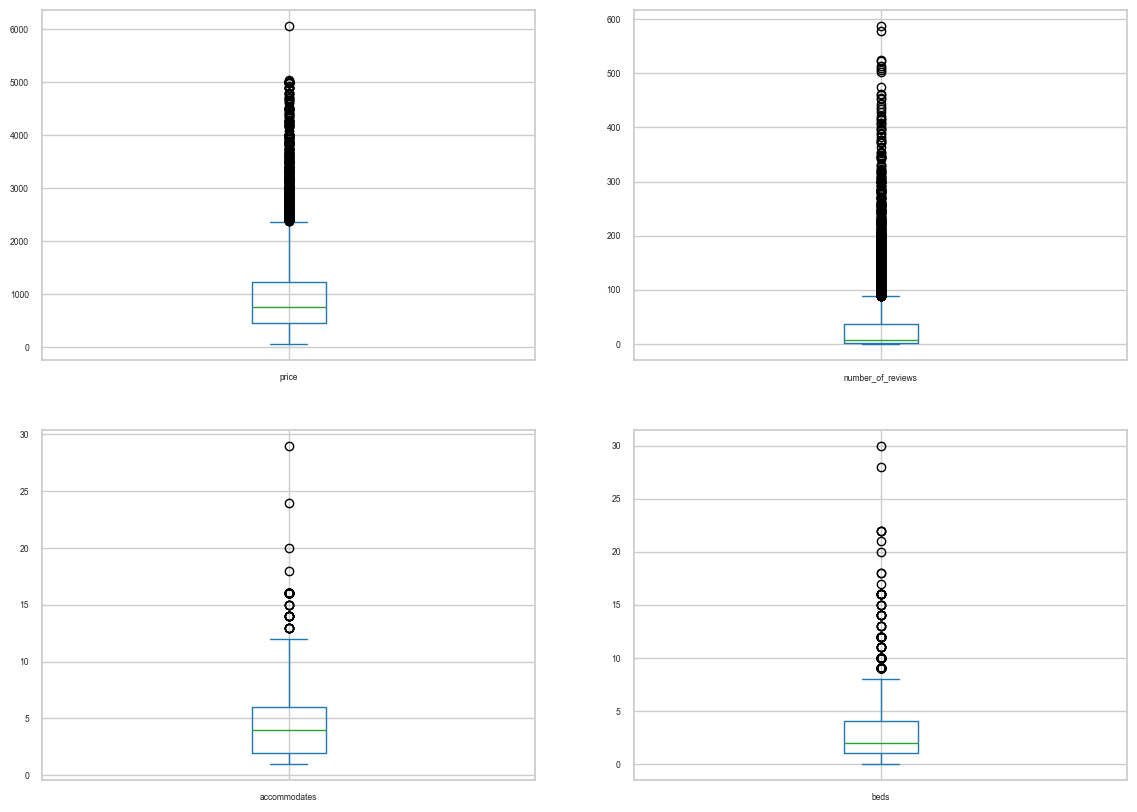

In [38]:
df[['price', 'number_of_reviews', 'accommodates', 'beds']].plot.box(subplots=True, figsize=(14,10), layout = (2,2));

In [39]:
df.isnull().sum()

apartment_id                      0
name                              3
description                      54
host_id                           0
neighbourhood_name                0
neighbourhood_district         3139
room_type                         0
accommodates                      0
bathrooms                        43
bedrooms                         39
beds                              8
amenities_list                   17
price                           171
minimum_nights                    0
maximum_nights                    0
has_availability                550
availability_30                   0
availability_60                   0
availability_90                   0
availability_365                  0
number_of_reviews                 0
first_review_date              1614
last_review_date               1615
review_scores_rating           1696
review_scores_accuracy         1705
review_scores_cleanliness      1699
review_scores_checkin          1710
review_scores_communication 

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 8000 non-null   int64  
 1   name                         7997 non-null   object 
 2   description                  7946 non-null   object 
 3   host_id                      8000 non-null   int64  
 4   neighbourhood_name           8000 non-null   object 
 5   neighbourhood_district       4861 non-null   object 
 6   room_type                    8000 non-null   object 
 7   accommodates                 8000 non-null   int64  
 8   bathrooms                    7957 non-null   object 
 9   bedrooms                     7961 non-null   object 
 10  beds                         7992 non-null   float64
 11  amenities_list               7983 non-null   object 
 12  price                        7829 non-null   float64
 13  minimum_nights    